# 分类算法学习笔记

这份 notebook 实际上覆盖了多种分类思路，不只是“跑几个 sklearn 模型”。它把分类任务里最常见的四类方法串了起来：
- KNN：基于距离做投票。
- 朴素贝叶斯：基于概率做判别。
- 决策树：基于规则递归划分。
- 随机森林：基于多棵树做集成。

学习时建议不要只盯着准确率，而要对比它们“为什么会这样分类”。


In [25]:
import time

from sklearn.datasets import load_iris, fetch_20newsgroups, fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestClassifier


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 先看数据集，是为了理解任务难度

不同数据集有不同特点：
- 鸢尾花：小而干净，适合入门。
- 新闻文本：高维稀疏，适合概率模型和文本向量化。
- 位置签到数据：更接近真实业务，噪声和类别不平衡问题都更明显。


In [2]:
# 鸢尾花数据集
li = load_iris()

print(li.data.shape)
# print(li.data)
print(li.feature_names)

print(li.target.shape)
# print(li.target)
print(li.target_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
(150,)
['setosa' 'versicolor' 'virginica']


In [3]:
# 划分训练集和测试集
# test_size: 测试集占比，random_state: 随机数种子，保证每次划分结果相同
x_train, x_test, y_train, y_test = train_test_split(
    li.data, li.target, test_size=0.25, random_state=1)

# print('训练集特征值和目标值:\n', x_train, y_train)
print('训练集特征值形状:\n', x_train.shape)
# print('测试集特征值和目标值:\n', x_test, y_test)
print('测试集特征值形状:\n', x_test.shape)

训练集特征值形状:
 (112, 4)
测试集特征值形状:
 (38, 4)


In [4]:
# 20newsgroups数据集
news = fetch_20newsgroups(subset='all', data_home='data')
print(type(news.data))

print(news.target.shape)
print(news.target[0])

print(len(news.data))
print(news.data[0])
print(news.target_names)

<class 'list'>
(18846,)
10
18846
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'com

In [5]:
# 加州房价数据集
house = fetch_california_housing(data_home='data')
print(type(house.data))
print(house.data.shape)
print(house.feature_names)
print(house.target.shape)
print(house.target_names)

<class 'numpy.ndarray'>
(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
(20640,)
['MedHouseVal']


---


## KNN 的核心思想

KNN 不是真的“学出一个参数化模型”，而是在预测时看离自己最近的 K 个邻居属于哪一类。

它的优缺点都很鲜明：
- 优点：直观、几乎不需要训练。
- 缺点：预测时开销大，对特征尺度敏感。

所以这里做标准化非常关键，否则某些量纲更大的特征会主导距离计算。


In [6]:
data = pd.read_csv('data/FBlocation/train.csv')

print(data.head())
print(data.shape)
print(data.info())
print(data.describe())

# inplace
data = data.query('x < 1.25 and x > 1.0 and y < 2.75 and y > 2.5')

   row_id       x       y  accuracy    time    place_id
0       0  0.7941  9.0809        54  470702  8523065625
1       1  5.9567  4.7968        13  186555  1757726713
2       2  8.3078  7.0407        74  322648  1137537235
3       3  7.3665  2.5165        65  704587  6567393236
4       4  4.0961  1.1307        31  472130  7440663949
(29118021, 6)
<class 'pandas.DataFrame'>
RangeIndex: 29118021 entries, 0 to 29118020
Data columns (total 6 columns):
 #   Column    Dtype  
---  ------    -----  
 0   row_id    int64  
 1   x         float64
 2   y         float64
 3   accuracy  int64  
 4   time      int64  
 5   place_id  int64  
dtypes: float64(2), int64(4)
memory usage: 1.3 GB
None
             row_id             x             y      accuracy          time  \
count  2.911802e+07  2.911802e+07  2.911802e+07  2.911802e+07  2.911802e+07   
mean   1.455901e+07  4.999770e+00  5.001814e+00  8.284912e+01  4.170104e+05   
std    8.405649e+06  2.857601e+00  2.887505e+00  1.147518e+02  2.311761

## 网格搜索不是可有可无

KNN 对 `n_neighbors` 和 `weights` 很敏感。网格搜索的意义，是用交叉验证系统地找到更合适的参数，而不是凭感觉拍脑袋设定。


In [7]:
print(data.head())
print(data.shape)
data.describe()

      row_id       x       y  accuracy    time    place_id
600      600  1.2214  2.7023        17   65380  6683426742
957      957  1.1832  2.6891        58  785470  6683426742
4345    4345  1.1935  2.6550        11  400082  6889790653
4735    4735  1.1452  2.6074        49  514983  6822359752
5580    5580  1.0089  2.7287        19  732410  1527921905
(17710, 6)


,row_id,x,y,accuracy,time,place_id
count,1.771000e+04,17710.000000,17710.000000,17710.000000,17710.000000,1.771000e+04
mean,1.450569e+07,1.122538,2.632309,82.482101,397551.263128,5.129895e+09
std,8.353805e+06,0.077086,0.070144,113.613227,234601.097883,2.357399e+09
min,6.000000e+02,1.000100,2.500100,1.000000,119.000000,1.012024e+09
25%,7.327816e+06,1.049200,2.573800,25.000000,174069.750000,3.312464e+09
50%,1.443071e+07,1.123300,2.642300,62.000000,403387.500000,5.261906e+09
75%,2.163463e+07,1.190500,2.687800,75.000000,602111.750000,6.766325e+09
max,2.911215e+07,1.249900,2.749900,1004.000000,786218.000000,9.980711e+09


In [8]:
time_value = pd.to_datetime(data['time'], unit='s')
time_value = pd.DatetimeIndex(time_value)

data['day'] = time_value.day
data['hour'] = time_value.hour
data['weekday'] = time_value.weekday
data.drop('time', axis=1, inplace=True)


print(data.shape)
data.head()

(17710, 8)


,row_id,x,y,accuracy,place_id,day,hour,weekday
600,600,1.2214,2.7023,17,6683426742,1,18,3
957,957,1.1832,2.6891,58,6683426742,10,2,5
4345,4345,1.1935,2.6550,11,6889790653,5,15,0
4735,4735,1.1452,2.6074,49,6822359752,6,23,1
5580,5580,1.0089,2.7287,19,1527921905,9,11,4


## 朴素贝叶斯为什么适合文本

文本经过词袋或 TF-IDF 后，本质上是高维稀疏计数特征。多项式朴素贝叶斯正适合这种输入形式。

它之所以叫“朴素”，是因为假设特征条件独立。这个假设在现实里不完全成立，但在文本分类里往往 surprisingly 好用。


In [9]:
place_count = data.groupby('place_id').count()
place_count.describe()
place_count = place_count[place_count['row_id'] > 3].reset_index()
place_count.head()

,place_id,row_id,x,y,accuracy,day,hour,weekday
0,1097200869,1044,1044,1044,1044,1044,1044,1044
1,1228935308,120,120,120,120,120,120,120
2,1267801529,58,58,58,58,58,58,58
3,1278040507,15,15,15,15,15,15,15
4,1285051622,21,21,21,21,21,21,21


In [10]:
data = data[data['place_id'].isin(place_count['place_id'])]
print(data.shape)
data.head()

(16918, 8)


,row_id,x,y,accuracy,place_id,day,hour,weekday
600,600,1.2214,2.7023,17,6683426742,1,18,3
957,957,1.1832,2.6891,58,6683426742,10,2,5
4345,4345,1.1935,2.6550,11,6889790653,5,15,0
4735,4735,1.1452,2.6074,49,6822359752,6,23,1
5580,5580,1.0089,2.7287,19,1527921905,9,11,4


In [11]:
y = data['place_id']
x = data.drop(['place_id'], axis=1)
x = x.drop(['row_id'], axis=1)

print(x.shape)
print(x.columns)

(16918, 6)
Index(['x', 'y', 'accuracy', 'day', 'hour', 'weekday'], dtype='str')


## 决策树在学什么

决策树的过程可以理解成不断提问：
- 某个特征是否大于阈值？
- 某个类别取值是否属于某个集合？

每一次划分都试图让子节点更“纯”，也就是同类样本更集中。常见指标有信息增益、信息增益率和基尼指数。


In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=1)

std = StandardScaler()
x_train = std.fit_transform(x_train)
x_test = std.transform(x_test)

print(x_train.shape)
print(x_test.shape)

(12688, 6)
(4230, 6)


## 随机森林为什么比单棵树稳

单棵决策树很容易过拟合，而随机森林通过两层随机性降低这种风险：
- 对样本做 bootstrap 抽样。
- 对特征做随机子集选择。

最后再让多棵树投票，通常能得到更稳定的泛化效果。


In [ ]:
# 1. KNN算法
# 算法原理：KNN（K-Nearest Neighbors）算法是一种基于实例的学习方法，它通过计算待分类样本与训练样本之间的距离
# 选择距离最近的K个样本，然后根据这K个样本的类别进行投票，决定待分类样本的类别。
# 公式：距离计算公式通常使用欧氏距离，d(x, y) = sqrt(sum((x_i - y_i)^2))
# 适用场景：KNN算法适用于分类和回归问题，特别适合于数据分布不均匀的情况。它在小规模数据集上表现良好，但在大规模数据集上可能效率较低。
# 参数说明：
# n_neighbors: KNN算法中的K值，表示选择距离最近的K个样本进行投票，通常需要通过交叉验证来选择最佳的K值。
# weights: KNN算法中的权重参数，表示在投票时是否考虑距离的权重，常用的取值有'uniform'（所有邻居权重相同）和'distance'（邻居权重与距离成反比）。

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(knn.score(x_test, y_test))

0.4806146572104019


In [14]:
# 网格搜索
param = {'n_neighbors': [i for i in range(1, 21, 2)], 'weights': [
    'uniform', 'distance']}

# cv: 交叉验证的折数，默认为5，即将训练集划分为5份，每次使用其中4份进行训练，剩余1份进行验证
# 重复5次，每次使用不同的验证集，最终取平均值作为模型的性能评估指标。
gc = GridSearchCV(knn, param_grid=param, cv=3)
gc.fit(x_train, y_train)

print("网格搜索准确率:", gc.score(x_test, y_test))
print("最佳结果:", gc.best_score_)
print("最佳参数:", gc.best_params_)

c:\DevEnv\python_venv\.any\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


网格搜索准确率: 0.4978723404255319
最佳结果: 0.48132097020069126
最佳参数: {'n_neighbors': 13, 'weights': 'distance'}


In [15]:
# 分类报告
# TP: 真阳性，模型正确预测为正类的样本数量
# FP: 假阳性，模型错误预测为正类的样本数量
# TN: 真阴性，模型正确预测为负类的样本数量
# FN: 假阴性，模型错误预测为负类的样本数量
# Precision: 精确率，TP / (TP + FP)，表示模型预测为正类的样本中实际为正类的比例
# Recall: 召回率，TP / (TP + FN)，表示实际为正类的样本中被模型正确预测为正类的比例
# F1-score: 综合考虑精确率和召回率的指标，F1 = 2 * (Precision * Recall) / (Precision + Recall)，当Precision和Recall相等时，F1-score达到最大值。
# support: 支持度，表示每个类别在测试集中出现的样本数量
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  1097200869       0.57      0.90      0.70       249
  1228935308       0.12      0.26      0.16        19
  1267801529       0.00      0.00      0.00        14
  1278040507       0.00      0.00      0.00         3
  1285051622       0.08      0.33      0.13         3
  1325949552       0.00      0.00      0.00         4
  1435128522       0.17      0.27      0.21        44
  1446331025       0.00      0.00      0.00         2
  1459761417       0.00      0.00      0.00         1
  1479000473       0.30      0.60      0.40         5
  1527921905       0.00      0.00      0.00         4
  1582523772       0.00      0.00      0.00        10
  1602053545       0.00      0.00      0.00         2
  1623524137       0.00      0.00      0.00         0
  1640245124       0.20      0.27      0.23        11
  1692546951       0.00      0.00      0.00         1
  1705420368       0.00      0.00      0.00         4
  1707158011       0.00    

c:\DevEnv\python_venv\.any\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\DevEnv\python_venv\.any\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\DevEnv\python_venv\.any\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\DevEnv\python_venv\.any\Lib

In [16]:
# ROC-AUC 曲线
# 以FPR为横轴，TPR为纵轴绘制的曲线，ROC曲线下面积（AUC）越接近1，模型性能越好。
# FPR: 假阳性率，FP / (FP + TN)，表示实际为负类的样本中被模型错误预测为正类的比例
# TPR: 真阳性率，TP / (TP + FN)，表示实际为正类的样本中被模型正确预测为正类的比例
# AUC: ROC曲线下面积，取值范围为0到1，AUC越接近1，模型性能越好。

| 实际类别 \ 预测类别 | Positive（预测为正类） | Negative（预测为负类） |
| --- | --- | --- |
| Positive（实际为正类） | TP（真正例） | FN（假负例） |
| Negative（实际为负类） | FP（假正例） | TN（真负例） |

---

In [17]:
news = fetch_20newsgroups(subset='all', data_home='data')
print(len(news.data))
print(news.data[0])
print(news.target)
print(news.target_names)


18846
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


[10  3 17 ...  3  1  7]
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.s

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    news.data, news.target, test_size=0.25, random_state=1)

tf = TfidfVectorizer()
x_train = tf.fit_transform(x_train)
x_test = tf.transform(x_test)

In [ ]:
# 2. 朴素贝叶斯算法
# MultinomialNB: 适用于多项式分布的朴素贝叶斯分类器，常用于文本分类问题
# 先验概率：P(C) 表示类别C在训练数据中出现的概率，可以通过计算每个类别的样本数量除以总样本数量来估计。
# 条件概率：P(X|C) 表示在类别C的条件下，特征X出现的概率，可以通过计算在类别C中具有特征X的样本数量除以类别C中的总样本数量来估计。
# 后验概率：P(C|X) 表示在给定特征X的条件下，类别C的概率，可以通过贝叶斯定理计算得到：P(C|X) = P(X|C) * P(C) / P(X)
# 其中P(X)是特征X在所有类别中的总概率，可以通过计算具有特征X的样本数量除以总样本数量来估计。
# 拉普拉斯平滑：为了避免在计算条件概率时出现零概率问题，可以使用拉普拉斯平滑技术，即在计算条件概率时对每个类别的样本数量加1，对总样本数量加上类别数。
# 适用场景：朴素贝叶斯算法适用于文本分类、垃圾邮件过滤、情感分析等领域，特别适合于高维数据和大规模数据集。

# 参数说明：
# alpha: 平滑参数，默认为1.0，表示拉普拉斯平滑的程度，alpha越大，平滑效果越强，可以防止零概率问题，但过大的alpha可能会导致模型过于简单。
# fit_prior: 是否学习先验概率，默认为True，如果设置为False，则所有类别的先验概率将被设置为1/n_classes。
mlt = MultinomialNB()
mlt.fit(x_train, y_train)
print("准确率:", mlt.score(x_test, y_test))

y_pred = mlt.predict(x_test)

print(classification_report(y_test, y_pred))

准确率: 0.8518675721561969
              precision    recall  f1-score   support

           0       0.91      0.77      0.83       199
           1       0.83      0.79      0.81       242
           2       0.89      0.83      0.86       263
           3       0.80      0.83      0.81       262
           4       0.90      0.88      0.89       234
           5       0.92      0.85      0.88       230
           6       0.96      0.67      0.79       257
           7       0.90      0.87      0.88       265
           8       0.90      0.95      0.92       251
           9       0.89      0.96      0.93       226
          10       0.95      0.98      0.96       262
          11       0.76      0.97      0.85       257
          12       0.84      0.80      0.82       229
          13       0.97      0.86      0.91       249
          14       0.92      0.96      0.94       256
          15       0.55      0.98      0.70       243
          16       0.76      0.96      0.85       234
   

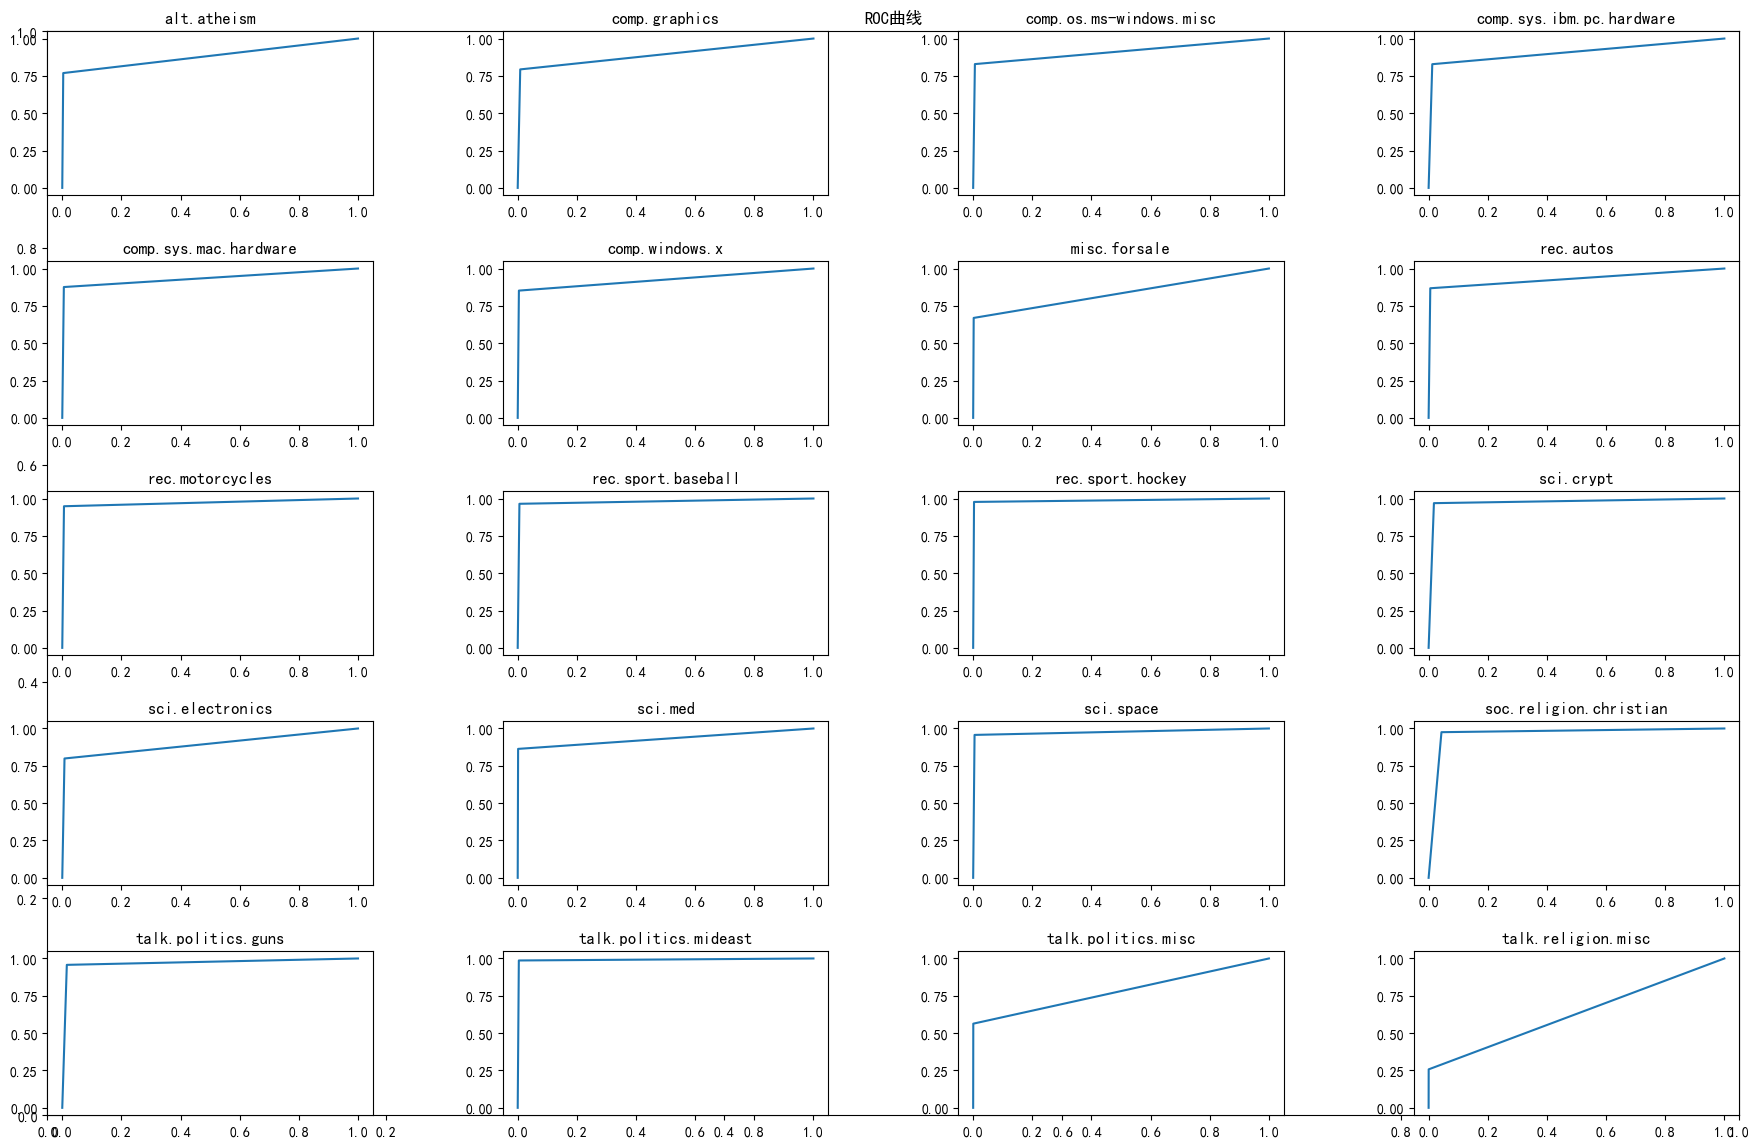

In [20]:
# AUC-ROC曲线
plt.figure(figsize=(18, 12))
plt.title('ROC曲线')
for i in range(len(news.target_names)):
    plt.subplot(5, 4, i + 1)
    # 计算FPR和TPR
    fpr, tpr, _ = roc_curve(
        (y_test == i).astype(int), (y_pred == i).astype(int))
    plt.plot(fpr, tpr, label=f'类别 {news.target_names[i]}')
    # title
    plt.title(news.target_names[i])
plt.tight_layout()
# 间距加大
plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.show()

---

In [21]:
titan = pd.read_csv('data/titanic.csv')
titan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row.names  1313 non-null   int64  
 1   pclass     1313 non-null   str    
 2   survived   1313 non-null   int64  
 3   name       1313 non-null   str    
 4   age        633 non-null    float64
 5   embarked   821 non-null    str    
 6   home.dest  754 non-null    str    
 7   room       77 non-null     str    
 8   ticket     69 non-null     str    
 9   boat       347 non-null    str    
 10  sex        1313 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 113.0 KB


In [22]:
# 男性和女性存活率
titan.groupby('sex')['survived'].mean()

sex
female    0.663067
male      0.167059
Name: survived, dtype: float64

In [23]:
x = titan[['pclass', 'age', 'sex']]
y = titan['survived']

x.fillna(x['age'].mean(), inplace=True)
print(x.info())

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=1)

dv = DictVectorizer(sparse=False)
# orient='records'：每行数据转换为一个字典，键为列名，值为对应的值
# x_train.to_dict(orient='records')
x_train = dv.fit_transform(x_train.to_dict(orient='records'))
x_test = dv.transform(x_test.to_dict(orient='records'))

<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  1313 non-null   str    
 1   age     1313 non-null   float64
 2   sex     1313 non-null   str    
dtypes: float64(1), str(2)
memory usage: 30.9 KB
None


In [ ]:
# 3. 决策树算法
# 算法原理：决策树算法是一种基于树结构的分类和回归方法，通过递归地将数据集划分成更小的子集来构建决策树。
# 每个节点表示一个特征，每个分支表示一个特征值，每个叶子节点表示一个类别或一个数值。
# 决策树的构建过程通常使用递归的方法，选择最优特征进行划分，直到满足停止条件（如达到最大深度、叶子节点样本数量小于某个阈值等）。
# 信息增益：信息增益是决策树算法中常用的特征选择指标，表示通过选择某个特征进行划分后，数据集的不确定性减少的程度。信息增益越大，说明该特征对于分类的贡献越大。
# 计算公式：信息增益 = 熵(父节点) - 加权平均熵(子节点)，其中熵是衡量数据集纯度的指标，熵越小，数据集越纯。
# 熵的计算公式：熵(S) = -sum(p_i * log2(p_i))，其中p_i是类别i在数据集S中的概率。
# 适用场景：决策树算法适用于分类和回归问题，特别适合于处理非线性关系和具有复杂特征交互的数据集。它在小规模数据集上表现良好，但在大规模数据集上可能过拟合.


# 参数说明：
# criterion: 决策树算法的一个重要参数，表示在构建决策树时，选择特征进行划分的标准。
# max_depth: 决策树的最大深度，限制树的深度可以防止过拟合
# min_samples_leaf: 叶子节点最少样本数，限制叶子节点的样本数量可以防止过拟合，特别是在数据集较小或特征较多的情况下。
dec = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=5)
dec.fit(x_train, y_train)

print("准确率:", dec.score(x_test, y_test))
y_pred = dec.predict(x_test)
print(classification_report(y_test, y_pred))


export_graphviz(
    dec, out_file='tree.dot',
    feature_names=dv.get_feature_names_out(),
    class_names=['未存活', '存活'],
    filled=True, rounded=True
)

准确率: 0.8328267477203647
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       198
           1       0.85      0.70      0.77       131

    accuracy                           0.83       329
   macro avg       0.84      0.81      0.82       329
weighted avg       0.83      0.83      0.83       329



---


In [30]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=1)

dv = DictVectorizer(sparse=False)
# orient='records'：每行数据转换为一个字典，键为列名，值为对应的值
# x_train.to_dict(orient='records')
x_train = dv.fit_transform(x_train.to_dict(orient='records'))
x_test = dv.transform(x_test.to_dict(orient='records'))

In [32]:
# 4. 随机森林算法
# 机器学习中随机森林是一个包含多个决策树的集成学习方法，通过构建多个决策树并结合它们的预测结果来提高模型的性能和稳定性。
# 随机森林算法通过引入随机性来构建每棵决策树，从而减少过拟合的风险。

# 参数说明：
# n_jobs: 用于指定并行运行的线程数，-1表示使用所有可用的处理器核心来加速训练过程。
# n_estimators: 随机森林中决策树的数量，增加树的数量通常可以提高模型的性能，但也会增加计算成本。
# max_depth: 决策树的最大深度，限制树的生长以防止过拟合。
# min_samples_split: 分割内部节点所需的最小样本数。
# min_samples_leaf: 叶节点所需的最小样本数。
# bootstrap: 是否使用自助法（bootstrap）来构建决策树，默认为True。

rf = RandomForestClassifier(n_jobs=-1)
gc = GridSearchCV(rf, param_grid={'n_estimators': [
                  1500, 2000, 4000], 'max_depth': [3, 5, 8]}, cv=3)
gc.fit(x_train, y_train)

print("准确率:", gc.score(x_test, y_test))
print("最佳结果:", gc.best_score_)
print("最佳参数:", gc.best_params_)

准确率: 0.8419452887537994
最佳结果: 0.8119918699186991
最佳参数: {'max_depth': 5, 'n_estimators': 1500}


## 学习检查清单

完成本 notebook 后，可以尝试回答：
- 这个任务属于监督学习、无监督学习，还是特征处理流程？
- 当前算法依赖哪些关键假设，什么数据场景下可能失效？
- 代码中哪些步骤是在防止数据泄漏或过拟合？
- 如果指标不理想，应该优先调整特征、模型参数还是评估方式？
